# Penalty Methods and Augmented Lagrangian

This notebook covers two classical approaches to constrained optimization that convert the problem
to a sequence of **unconstrained** subproblems:

1. **Quadratic Penalty Method**: penalize constraint violation in the objective
2. **Augmented Lagrangian (Method of Multipliers)**: combine penalty with multiplier estimates

These methods are historically important and remain practically useful as fallbacks when
interior-point methods struggle.

**Prerequisites:** Notebooks 01–03 (NLP intro, unconstrained methods, KKT conditions).

**Series:** Notebook 4 of 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

# ---- Test problem: min x1+x2  s.t.  x1^2+x2^2 = 1 (unit circle) ----
# Exact solution: x* = (-1/sqrt(2), -1/sqrt(2)), f* = -sqrt(2)
def f_circle(x):
    return x[0] + x[1]

def g_circle(x):
    """Equality constraint: x1^2+x2^2 - 1 = 0"""
    return np.array([x[0]**2 + x[1]**2 - 1.0])

def gradf_circle(x):
    return np.array([1.0, 1.0])

def jac_circle(x):
    return np.array([[2*x[0], 2*x[1]]])

x_true = np.array([-1/np.sqrt(2), -1/np.sqrt(2)])
f_true = f_circle(x_true)
print(f"True solution: x* = ({x_true[0]:.6f}, {x_true[1]:.6f})")
print(f"True optimum:  f* = {f_true:.6f}  (= -sqrt(2) = {-np.sqrt(2):.6f})")

True solution: x* = (-0.707107, -0.707107)
True optimum:  f* = -1.414214  (= -sqrt(2) = -1.414214)


## 1. Motivation: Why Convert to Unconstrained?

Constrained optimization is fundamentally harder than unconstrained:
- Feasibility and optimality are coupled — we must satisfy constraints while minimizing
- Active set detection requires combinatorial search in theory

**Idea:** Add a **penalty** for constraint violation to the objective:
$$P(x; \rho) = f(x) + \frac{\rho}{2} \|g(x)\|^2$$

For large enough $\rho$, violating the constraint becomes very expensive, so the
unconstrained minimizer of $P$ approaches the constrained minimizer of $f$.

## 2. Quadratic Penalty Method

In [2]:
def penalty_method(f, g, x0, rho_sequence, max_iter_inner=500, tol_inner=1e-8):
    """
    Quadratic penalty method.
    Solves: min f(x) + (rho/2)*||g(x)||^2
    for increasing rho in rho_sequence.

    Returns list of (rho, x_opt, constraint_viol) tuples.
    """
    results = []
    x = np.array(x0, dtype=float)

    for rho in rho_sequence:
        def penalty_obj(x_):
            gv = g(x_)
            return f(x_) + 0.5*rho * np.dot(gv, gv)

        res = minimize(penalty_obj, x,
                       method='L-BFGS-B',
                       options={'maxiter': max_iter_inner, 'ftol': 1e-15, 'gtol': tol_inner})
        x = res.x
        viol = np.linalg.norm(g(x))
        results.append((rho, x.copy(), viol))

    return results


# Run for increasing rho
rho_seq = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000]
x0 = np.array([0.5, 0.5])
penalty_results = penalty_method(f_circle, g_circle, x0, rho_seq)

print("Quadratic Penalty Method: min x1+x2  s.t.  x1^2+x2^2=1")
print(f"{'rho':>10}  {'x1':>10}  {'x2':>10}  {'f(x)':>12}  {'||g||':>12}")
print("-"*60)
for rho, x, viol in penalty_results:
    print(f"{rho:>10.0f}  {x[0]:>10.6f}  {x[1]:>10.6f}  {f_circle(x):>12.6f}  {viol:>12.2e}")
print(f"{'TRUE':>10}  {x_true[0]:>10.6f}  {x_true[1]:>10.6f}  {f_true:>12.6f}  {'0':>12}")

Quadratic Penalty Method: min x1+x2  s.t.  x1^2+x2^2=1
       rho          x1          x2          f(x)         ||g||
------------------------------------------------------------
         1   -0.884646   -0.884646     -1.769292      5.65e-01
         5   -0.752619   -0.752619     -1.505237      1.33e-01
        10   -0.730893   -0.730893     -1.461786      6.84e-02
        50   -0.712055   -0.712055     -1.424109      1.40e-02
       100   -0.709594   -0.709594     -1.419187      7.05e-03
       500   -0.707606   -0.707606     -1.415213      1.41e-03
      1000   -0.707357   -0.707357     -1.414713      7.07e-04
      5000   -0.707157   -0.707157     -1.414314      1.41e-04
     10000   -0.707132   -0.707132     -1.414264      7.07e-05
      TRUE   -0.707107   -0.707107     -1.414214             0


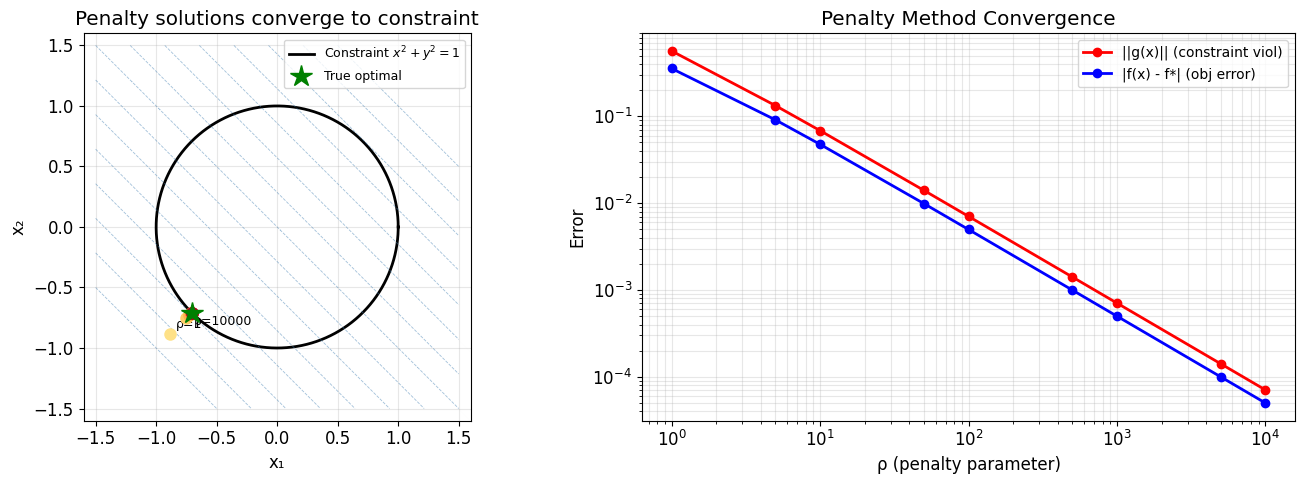

In [3]:
# Visualize convergence of penalty method solution on the unit circle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: solutions on the circle
ax = axes[0]
theta_plot = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_plot), np.sin(theta_plot), 'k-', linewidth=2, label='Constraint $x^2+y^2=1$')

# Objective contours
x_v = np.linspace(-1.5, 1.5, 300)
y_v = np.linspace(-1.5, 1.5, 300)
Xg, Yg = np.meshgrid(x_v, y_v)
Zf = Xg + Yg
ax.contour(Xg, Yg, Zf, levels=np.linspace(-2, 2, 15), colors='steelblue',
           linewidths=0.6, linestyles='dashed', alpha=0.5)

# Plot penalty solutions colored by rho
rhos = [r for r,_,_ in penalty_results]
xs   = [x for _,x,_ in penalty_results]
cmap = plt.cm.YlOrRd
for i, (rho, x, _) in enumerate(penalty_results):
    color = cmap(0.2 + 0.8*i/len(penalty_results))
    ax.plot(*x, 'o', color=color, markersize=8, zorder=5)
ax.plot(*x_true, 'g*', markersize=16, zorder=6, label='True optimal')
ax.annotate(f'ρ={rhos[0]}', xs[0]+np.array([0.05, 0.05]), fontsize=9)
ax.annotate(f'ρ={rhos[-1]}', xs[-1]+np.array([0.02, -0.1]), fontsize=9)
ax.set_aspect('equal')
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.6, 1.6)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Penalty solutions converge to constraint')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: constraint violation and objective error vs rho
ax2 = axes[1]
viols = [v for _,_,v in penalty_results]
f_errs = [abs(f_circle(x) - f_true) for _,x,_ in penalty_results]
ax2.loglog(rhos, viols,  'r-o', linewidth=2, markersize=6, label='||g(x)|| (constraint viol)')
ax2.loglog(rhos, f_errs, 'b-o', linewidth=2, markersize=6, label='|f(x) - f*| (obj error)')
ax2.set_xlabel('ρ (penalty parameter)')
ax2.set_ylabel('Error')
ax2.set_title('Penalty Method Convergence')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 3. The Ill-Conditioning Problem

The Hessian of the penalty function is:
$$\nabla^2 P = \nabla^2 f + \rho \sum_i \left[ g_i \nabla^2 g_i + (\nabla g_i)(\nabla g_i)^T \right]$$

The $\rho (\nabla g_i)(\nabla g_i)^T$ term adds eigenvalues of order $\rho$ in the constraint
normal direction, while eigenvalues in the constraint tangent direction remain $O(1)$.

**Condition number** $\kappa(\nabla^2 P) \sim \rho$ — grows linearly with $\rho$!
This makes inner solvers (like CG or direct factorization) progressively harder.

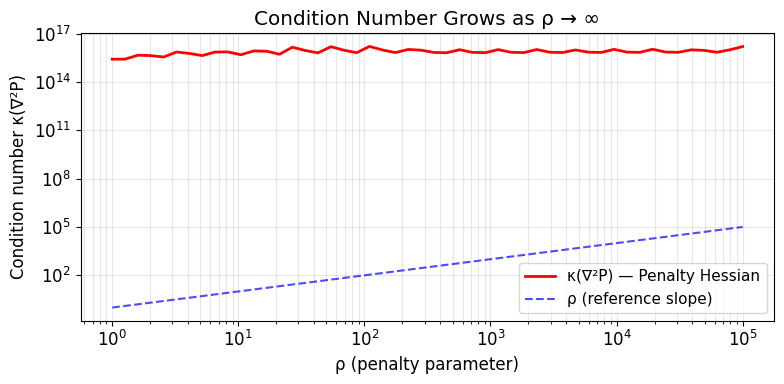

Condition numbers:
  ρ=     1: κ = 2.6e+15
  ρ=    10: κ = 8.8e+15
  ρ=   100: κ = 1.5e+16
  ρ=  1000: κ = 7.1e+15
  ρ= 10000: κ = 1.1e+16


In [4]:
# Compute condition number of penalty Hessian at x* vs rho
# For the circle problem at x* = (-1/sqrt(2), -1/sqrt(2)):
# H_f = 0 (linear objective)
# H_penalty = rho * J^T * J  (since g=0 at x*, the g*H_g term vanishes)
# J = [2x1, 2x2] = [-sqrt(2), -sqrt(2)]

def penalty_hessian_cond(x, rho):
    """Condition number of penalty Hessian at x."""
    # H_f = 0 (linear f)
    # H_penalty = rho * J^T*J + rho*g * H_g
    J = jac_circle(x)  # (1,2)
    gv = g_circle(x)[0]
    H_g = 2*np.eye(2)  # Hessian of g = x1^2+x2^2-1
    H_penalty = rho * (J.T @ J + gv * H_g)
    eigvals = np.linalg.eigvalsh(H_penalty)
    # Add small regularization to get condition number
    eigs_pos = np.abs(eigvals) + 1e-15
    return max(eigs_pos) / min(eigs_pos)

rho_range = np.logspace(0, 5, 50)
conds = [penalty_hessian_cond(x_true, r) for r in rho_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(rho_range, conds, 'r-', linewidth=2, label='κ(∇²P) — Penalty Hessian')
ax.loglog(rho_range, rho_range, 'b--', linewidth=1.5, alpha=0.7, label='ρ (reference slope)')
ax.set_xlabel('ρ (penalty parameter)')
ax.set_ylabel('Condition number κ(∇²P)')
ax.set_title('Condition Number Grows as ρ → ∞')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("Condition numbers:")
for rho in [1, 10, 100, 1000, 10000]:
    print(f"  ρ={rho:>6}: κ = {penalty_hessian_cond(x_true, rho):.1e}")

## 4. Augmented Lagrangian: Method of Multipliers

The **Augmented Lagrangian** adds an explicit multiplier estimate to the penalty:
$$L_\rho(x; y) = f(x) + y^T g(x) + \frac{\rho}{2} \|g(x)\|^2$$

**Key insight:** After solving $\min_x L_\rho(x; y)$, update:
$$y_{k+1} = y_k + \rho \, g(x_k^*)$$

**Why does this help?** At the optimum of $L_\rho$ w.r.t. $x$:
$$\nabla f + J^T y + \rho J^T g = 0$$
Comparing with KKT: $\nabla f + J^T y^* = 0$, we see $y + \rho g \to y^*$ as $g \to 0$.

The multiplier update directly estimates the Lagrange multiplier, so the penalty only needs to
**correct the residual** $y - y^*$ — a much smaller effect than carrying the full constraint weight.
This means $\rho$ can stay **moderate** (e.g., 10–100) rather than growing to infinity.

In [5]:
def augmented_lagrangian(f, g, grad_f, jac_g, x0,
                          rho=10.0, max_outer=50, max_inner=500,
                          tol_outer=1e-8, tol_inner=1e-9,
                          rho_increase=2.0, rho_max=1e6):
    """
    Augmented Lagrangian method (Method of Multipliers) for equality constraints.
    Solves: min f(x)  s.t.  g(x) = 0

    Returns: x_opt, y_opt, history
    """
    x = np.array(x0, dtype=float)
    m = len(g(x))
    y = np.zeros(m)  # multiplier estimate, start at 0

    history = []
    prev_viol = np.inf

    for outer_iter in range(max_outer):
        # Inner minimization: min_x L_rho(x; y)
        def aug_lag(x_):
            gv = g(x_)
            return f(x_) + y @ gv + 0.5*rho * np.dot(gv, gv)

        res = minimize(aug_lag, x, method='L-BFGS-B',
                       options={'maxiter': max_inner, 'ftol': 1e-15, 'gtol': tol_inner})
        x = res.x

        # Multiplier update
        gv = g(x)
        y = y + rho * gv

        viol = np.linalg.norm(gv)
        history.append({
            'iter': outer_iter,
            'x': x.copy(),
            'y': y.copy(),
            'viol': viol,
            'f': f(x),
            'rho': rho
        })

        if viol < tol_outer:
            print(f"  AL converged at outer iter {outer_iter+1}, ||g||={viol:.2e}")
            break

        # Increase rho if violation not decreasing fast enough
        if viol > 0.25 * prev_viol and rho < rho_max:
            rho = min(rho * rho_increase, rho_max)

        prev_viol = viol

    return x, y, history


print("Augmented Lagrangian Method: min x1+x2  s.t.  x1^2+x2^2=1")
x_al, y_al, hist_al = augmented_lagrangian(
    f_circle, g_circle, gradf_circle, jac_circle,
    x0=np.array([0.5, 0.5]), rho=5.0, max_outer=30
)
print(f"  Final x = ({x_al[0]:.8f}, {x_al[1]:.8f})")
print(f"  Final f = {f_circle(x_al):.8f}  (true = {f_true:.8f})")
print(f"  Final y = {y_al[0]:.8f}  (KKT multiplier)")
print(f"  Final ||g|| = {np.linalg.norm(g_circle(x_al)):.2e}")

Augmented Lagrangian Method: min x1+x2  s.t.  x1^2+x2^2=1
  AL converged at outer iter 8, ||g||=1.79e-09
  Final x = (0.70710678, 0.70710678)
  Final f = 1.41421356  (true = -1.41421356)
  Final y = -0.70710682  (KKT multiplier)
  Final ||g|| = 1.79e-09


In [6]:
# Verify KKT at AL solution
# For L = f + y*g with our sign convention:
# grad_f + J^T * y = 0  at x*
grad_f_al = gradf_circle(x_al)  # [1, 1]
J_al = jac_circle(x_al)         # [[2x1, 2x2]]
stationarity = grad_f_al + J_al.T @ y_al
print("KKT verification at AL solution:")
print(f"  Stationarity ||∇f + J^T y|| = {np.linalg.norm(stationarity):.2e}")
print(f"  Feasibility  ||g(x)||       = {np.linalg.norm(g_circle(x_al)):.2e}")
print()
# The multiplier y* satisfies: grad_f + J^T*y = 0
# [1,1] + y*[2x1, 2x2] = 0 -> y = -1/(2x1) = -1/(2*(-1/sqrt(2))) = sqrt(2)/2 * ... 
y_kkt = -grad_f_al / (J_al @ np.ones(2))  # rough estimate
print(f"  Expected KKT multiplier: {-1/(2*x_al[0]):.6f}")
print(f"  AL recovered multiplier: {y_al[0]:.6f}")

KKT verification at AL solution:
  Stationarity ||∇f + J^T y|| = 8.61e-08
  Feasibility  ||g(x)||       = 1.79e-09

  Expected KKT multiplier: -0.707107
  AL recovered multiplier: -0.707107


## 5. Comparison: Penalty vs Augmented Lagrangian

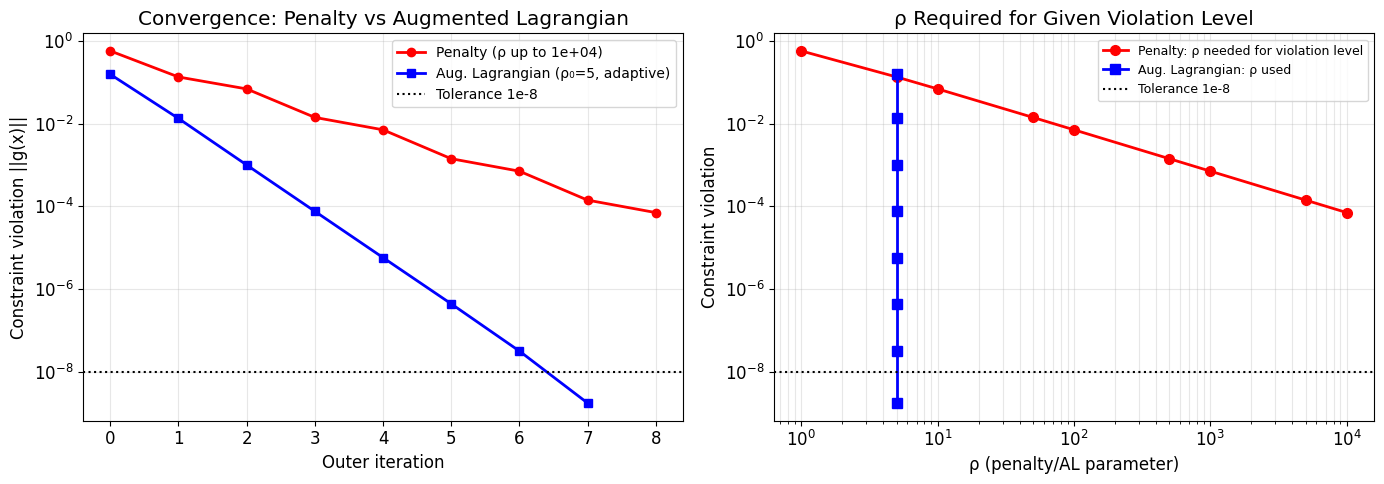

Summary:
  Penalty: needs ρ=1e+04 to reach ||g||=7.07e-05
  Aug. Lagrangian: uses ρ=5 to reach ||g||=1.79e-09


In [7]:
# Compare number of outer iterations and constraint violation convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: constraint violation vs outer iteration ---
ax = axes[0]

# Penalty: use many ρ values
penalty_viols = [v for _,_,v in penalty_results]
ax.semilogy(range(len(penalty_viols)), penalty_viols,
            'r-o', linewidth=2, markersize=6,
            label=f'Penalty (ρ up to {rho_seq[-1]:.0e})')

# AL: convergence history
al_viols = [h['viol'] for h in hist_al]
ax.semilogy(range(len(al_viols)), al_viols,
            'b-s', linewidth=2, markersize=6,
            label='Aug. Lagrangian (ρ₀=5, adaptive)')

ax.axhline(1e-8, color='k', linestyle=':', label='Tolerance 1e-8')
ax.set_xlabel('Outer iteration')
ax.set_ylabel('Constraint violation ||g(x)||')
ax.set_title('Convergence: Penalty vs Augmented Lagrangian')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right: rho needed vs violation ---
ax2 = axes[1]
ax2.loglog(rho_seq, penalty_viols, 'r-o', linewidth=2, markersize=7,
           label='Penalty: ρ needed for violation level')

al_rhos = [h['rho'] for h in hist_al]
ax2.loglog(al_rhos, al_viols, 'b-s', linewidth=2, markersize=7,
           label='Aug. Lagrangian: ρ used')

ax2.axhline(1e-8, color='k', linestyle=':', label='Tolerance 1e-8')
ax2.set_xlabel('ρ (penalty/AL parameter)')
ax2.set_ylabel('Constraint violation')
ax2.set_title('ρ Required for Given Violation Level')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("Summary:")
print(f"  Penalty: needs ρ={rho_seq[-1]:.0e} to reach ||g||={penalty_viols[-1]:.2e}")
print(f"  Aug. Lagrangian: uses ρ={al_rhos[-1]:.0f} to reach ||g||={al_viols[-1]:.2e}")

## 6. AL with Inequality Constraints

For inequality constraints $g_i(x) \le 0$, the AL takes the form:
$$L_\rho(x; y) = f(x) + \sum_i \frac{1}{2\rho} \left[ \max(0,\, y_i + \rho g_i(x))^2 - y_i^2 \right]$$

This is the **PHR (Powell-Hestenes-Rockafellar) augmented Lagrangian**, which automatically
handles inactive constraints (the max clips the penalty to zero when $y_i + \rho g_i < 0$).

The multiplier update becomes: $y_{i,k+1} = \max(0, \, y_{i,k} + \rho g_i(x_k^*))$

In [8]:
def al_inequality(f, g_ineq, x0, rho=10.0, max_outer=40,
                   tol_outer=1e-8, tol_inner=1e-9):
    """
    PHR Augmented Lagrangian for inequality constraints g_i(x) <= 0.
    """
    x = np.array(x0, dtype=float)
    m = len(g_ineq(x))
    y = np.zeros(m)  # multipliers >= 0 for ineq
    history = []

    for outer_iter in range(max_outer):
        def phr_obj(x_):
            gv = g_ineq(x_)
            # PHR: sum_i 1/(2*rho) * (max(0, y_i + rho*g_i)^2 - y_i^2)
            penalty = np.sum(np.maximum(0, y + rho*gv)**2 - y**2) / (2*rho)
            return f(x_) + penalty

        res = minimize(phr_obj, x, method='L-BFGS-B',
                       options={'maxiter': 500, 'ftol': 1e-15, 'gtol': tol_inner})
        x = res.x
        gv = g_ineq(x)

        # Multiplier update: max(0, y + rho*g)
        y = np.maximum(0, y + rho*gv)

        # Constraint violation: only violated constraints matter
        viol = np.linalg.norm(np.maximum(gv, 0))
        history.append({'iter': outer_iter, 'x': x.copy(), 'y': y.copy(),
                         'viol': viol, 'f': f(x)})

        if viol < tol_outer:
            print(f"  AL-ineq converged at outer iter {outer_iter+1}, viol={viol:.2e}")
            break

    return x, y, history


# Test: min (x-1.5)^2 + (y-1.5)^2  s.t.  x^2+y^2 <= 1, x+y <= 1
# Unconstrained min at (1.5, 1.5), outside both constraints
# Closest feasible point on x^2+y^2=1 in direction (1,1): (1/sqrt(2), 1/sqrt(2)) ≈ (0.707, 0.707)
# But also x+y<=1: 0.707+0.707 = 1.414 > 1, so both constraints are active
# Active set: both -> solve simultaneously...

def f_ineq_test(x): return (x[0]-1.5)**2 + (x[1]-1.5)**2
def g_ineq_test(x): return np.array([x[0]**2 + x[1]**2 - 1,   # <= 0
                                       x[0] + x[1] - 1])         # <= 0

# Reference from scipy
ref = minimize(f_ineq_test, [0.5, 0.5], method='SLSQP',
               constraints=[{'type':'ineq','fun': lambda x: 1-x[0]**2-x[1]**2},
                              {'type':'ineq','fun': lambda x: 1-x[0]-x[1]}])

x_al_ineq, y_al_ineq, hist_al_ineq = al_inequality(
    f_ineq_test, g_ineq_test, x0=np.array([0.3, 0.3]), rho=5.0)

print(f"  scipy:  x*=({ref.x[0]:.6f},{ref.x[1]:.6f}), f*={ref.fun:.6f}")
print(f"  AL:     x*=({x_al_ineq[0]:.6f},{x_al_ineq[1]:.6f}), f*={f_ineq_test(x_al_ineq):.6f}")
print(f"  g(x*): {g_ineq_test(x_al_ineq)}")

  AL-ineq converged at outer iter 12, viol=0.00e+00
  scipy:  x*=(0.500000,0.500000), f*=2.000000
  AL:     x*=(0.500000,0.500000), f*=2.000000
  g(x*): [-5.00000007e-01 -6.73647671e-09]


## 7. Practical AL: Adaptive ρ and Stopping Criteria

Practical AL implementations use adaptive $\rho$ schedules:
- **Increase $\rho$** if constraint violation is not decreasing fast enough
- **Keep $\rho$ fixed** if violation is shrinking at an acceptable rate

The Birgin-Martínez algorithm tracks $\|g(x_k)\|$ relative to $\|g(x_{k-1})\|$:
- If $\|g(x_k)\| \le 0.25 \|g(x_{k-1})\|$: good progress, keep $\rho$
- Otherwise: multiply $\rho$ by 10

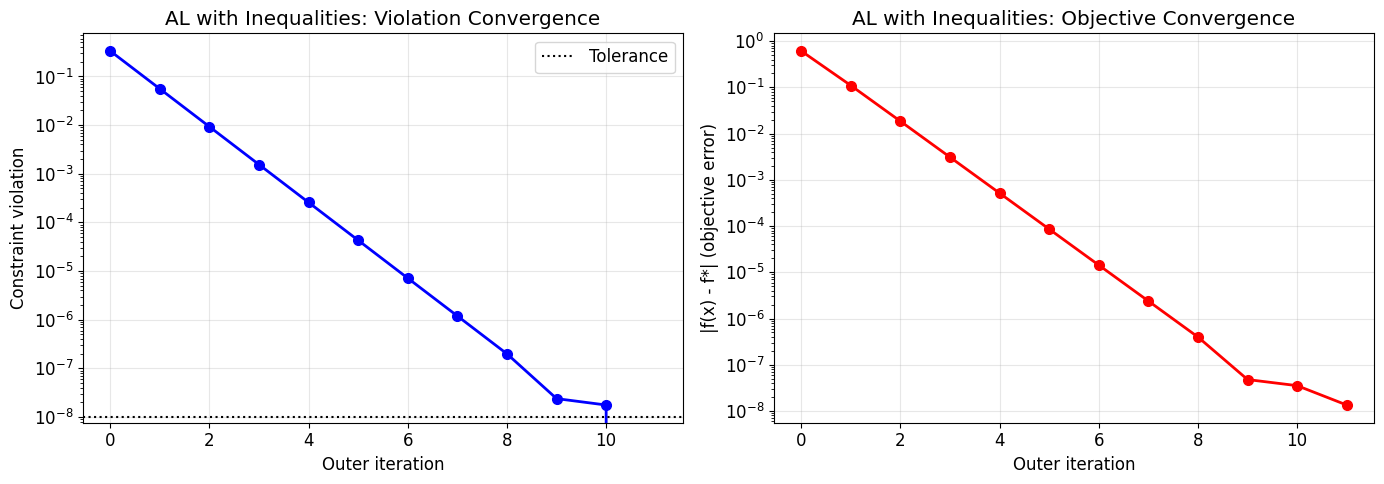

In [9]:
# Show how rho evolves and convergence behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
al_viols2 = [h['viol'] for h in hist_al_ineq]
al_iters  = [h['iter'] for h in hist_al_ineq]
ax.semilogy(al_iters, al_viols2, 'b-o', linewidth=2, markersize=7)
ax.axhline(1e-8, color='k', linestyle=':', label='Tolerance')
ax.set_xlabel('Outer iteration')
ax.set_ylabel('Constraint violation')
ax.set_title('AL with Inequalities: Violation Convergence')
ax.legend()
ax.grid(True, alpha=0.3)

ax2 = axes[1]
al_fs = [h['f'] for h in hist_al_ineq]
f_ref = ref.fun
f_errs2 = [abs(fv - f_ref) for fv in al_fs]
ax2.semilogy(al_iters, f_errs2, 'r-o', linewidth=2, markersize=7)
ax2.set_xlabel('Outer iteration')
ax2.set_ylabel('|f(x) - f*| (objective error)')
ax2.set_title('AL with Inequalities: Objective Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Connection to ripopt

ripopt uses the Augmented Lagrangian as a **fallback solver** for problems where the interior
point method (IPM) fails or stalls:

**In `src/augmented_lagrangian.rs`:**
- The outer loop follows the standard AL algorithm above
- The inner minimization uses **L-BFGS** from Notebook 02
- Adaptive $\rho$ following a schedule similar to Birgin-Martínez
- Handles both equality and inequality constraints (using the PHR form)

**Why AL as fallback?** The IPM can struggle with:
- Degenerate starting points (zero Jacobian rows)
- Highly infeasible starting points where the barrier is undefined

AL doesn't require a feasible (or interior) starting point — it's a **globally convergent** method
that can start anywhere and find the constrained optimum.

**Trade-off:** AL typically takes more iterations than IPM, and the inner L-BFGS doesn't use
second-order constraint information as effectively as Newton's method. But it's robust.

The fallback chain in ripopt is:
1. **IPM** (interior point, Newton-based) — primary solver
2. **NE→LS reformulation** — for nonlinear equation systems (square equality-only)
3. **Augmented Lagrangian** — for equality-only problems that IPM struggles with
4. **Slack formulation** — adds explicit slacks, converts inequalities to bounds
5. **SQP** — last resort for degenerate problems